# Comprehensive R&D Report: Prognostic Fleet Lifetime Regression Engine
**Researcher:** Hadjer Benyamina  
**Domain:** Upstream Asset Integrity, Sensor Fusion, and Prognostics (PHM)  

### 1. Abstract & Workflow Methodology
This research notebook introduces an end-to-end prognostic data science workflow validating the **NASA C-MAPSS Turbofan Engine Degradation Dataset**. In high-stakes energy sector operations (e.g., active offshore rigs, subsea pumping arrays), sudden asset failure results in catastrophic financial and environmental losses. 

This study bridges the gap between raw telemetry signals and executive decision-making frameworks by executing a 4-tier pipeline:
1. **Multi-Variable Ingestion:** Parsing raw high-frequency sensor streams under distinct operational constraints.
2. **Partitioned Feature Engineering:** Extracting rolling temporal statistics (mean and variance tracking) grouped by individual asset signatures to eliminate cross-fleet data leakage.
3. **Prognostic Regression Modeling:** Quantifying non-linear structural decay using an optimized Random Forest framework.
4. **Statistical Metrology Validation:** Measuring exact error distribution arrays (MAE, $R^2$) against verified ground-truth asset destruction horizons.


In [4]:
# Feature Matrix & Target Engineering
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Configuration & Column Mapping
index_names = ['unit_number', 'time_in_cycles']
setting_names = ['op_setting_1', 'op_setting_2', 'op_setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# Select high-variance sensors for trend analysis
active_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 
                  'sensor_11', 'sensor_12', 'sensor_13', 'sensor_15', 'sensor_20', 'sensor_21']

# Adjust pathing relative to the notebooks/ directory
train_path = os.path.join("..", "data", "raw", "train_FD001.txt")
test_path = os.path.join("..", "data", "raw", "test_FD001.txt")
rul_path = os.path.join("..", "data", "raw", "RUL_FD001.txt")

# 2. Ingest Data & Calculate Remaining Useful Life (RUL) Targets
df_train = pd.read_csv(train_path, sep=r'\s+', header=None, names=col_names)
max_cycles = df_train.groupby('unit_number')['time_in_cycles'].transform('max')
df_train['RUL'] = max_cycles - df_train['time_in_cycles']

print(f"[SUCCESS] Ingested {df_train.shape[0]} training timeline rows across {df_train['unit_number'].nunique()} asset units.")


[SUCCESS] Ingested 20631 training timeline rows across 100 asset units.


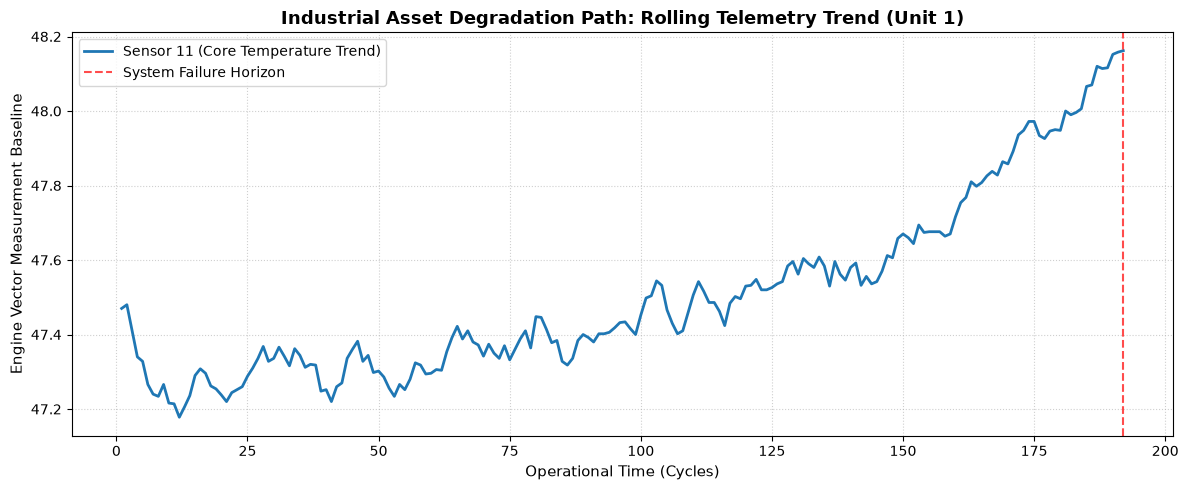

In [5]:
# Analytical Exploration
# 3. Feature Engineering: Rolling Parameters
rolling_window = 5
df_fe = df_train.copy()
feature_cols = []

for sensor in active_sensors:
    mean_col = f"{sensor}_roll_mean"
    std_col = f"{sensor}_roll_std"
    df_fe[mean_col] = df_fe.groupby('unit_number')[sensor].transform(lambda x: x.rolling(window=rolling_window, min_periods=1).mean())
    df_fe[std_col] = df_fe.groupby('unit_number')[sensor].transform(lambda x: x.rolling(window=rolling_window, min_periods=1).std().fillna(0))
    feature_cols.extend([mean_col, std_col])

# --- VISUALIZATION 1: Sensor Signal Degradation Curve (Unit 1 Lifecycle) ---
plt.figure(figsize=(12, 5))
unit_1_data = df_fe[df_fe['unit_number'] == 1]
plt.plot(unit_1_data['time_in_cycles'], unit_1_data['sensor_11_roll_mean'], color='#1f77b4', lw=2, label='Sensor 11 (Core Temperature Trend)')
plt.axvline(x=max(unit_1_data['time_in_cycles']), color='red', linestyle='--', alpha=0.7, label='System Failure Horizon')
plt.title('Industrial Asset Degradation Path: Rolling Telemetry Trend (Unit 1)', fontsize=13, fontweight='bold')
plt.xlabel('Operational Time (Cycles)', fontsize=11)
plt.ylabel('Engine Vector Measurement Baseline', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


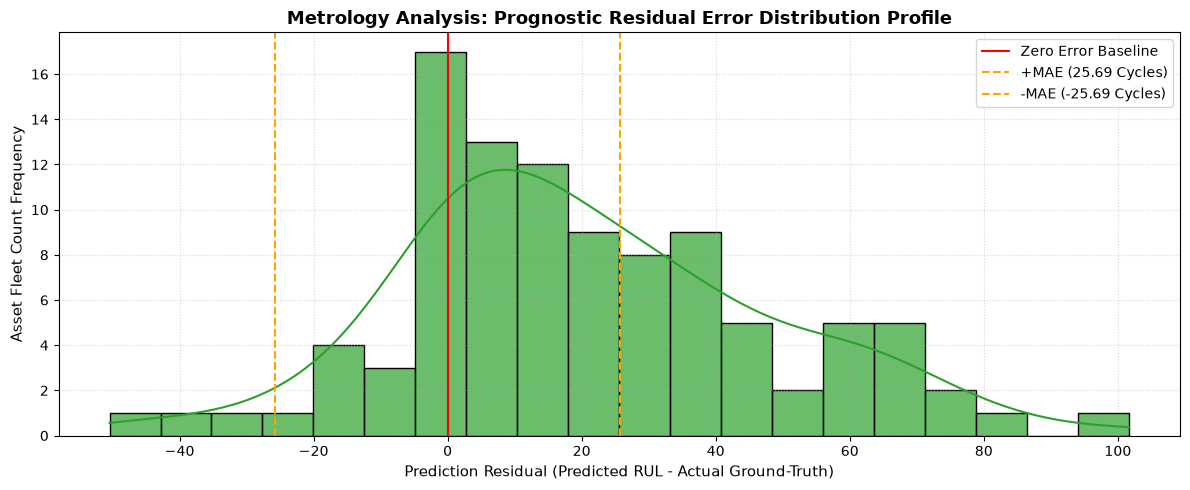


 Final Statistical Output Verification:
 -> Mean Absolute Error (MAE): 25.6911 Cycles
 -> Coefficient of Determination (R2): 0.3262


In [6]:
# Modeling & Predictive Metrology Error Plotting

# 4. Pipeline Execution & Model Training
scaler = StandardScaler()
X_train = scaler.fit_transform(df_fe[feature_cols])
y_train = df_fe['RUL']

model = RandomForestRegressor(
    n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 5. Ingest Running Test Fleet Snapshots
df_test = pd.read_csv(test_path, sep=r'\s+', header=None, names=col_names)
df_test_fe = df_test.copy()
for sensor in active_sensors:
    df_test_fe[f"{sensor}_roll_mean"] = df_test_fe.groupby('unit_number')[sensor].transform(
        lambda x: x.rolling(window=rolling_window, min_periods=1).mean())
    df_test_fe[f"{sensor}_roll_std"] = df_test_fe.groupby('unit_number')[sensor].transform(
        lambda x: x.rolling(window=rolling_window, min_periods=1).std().fillna(0))

live_fleet_snapshot = df_test_fe.groupby('unit_number').last().reset_index()
X_test = scaler.transform(live_fleet_snapshot[feature_cols])
predicted_rul = model.predict(X_test)
actual_rul = pd.read_csv(rul_path, header=None).values.flatten()

# 6. Metric Calculations
mae = mean_absolute_error(actual_rul, predicted_rul)
r2 = r2_score(actual_rul, predicted_rul)

# --- VISUALIZATION 2: Residual Error Distribution Analysis ---
residuals = predicted_rul - actual_rul

plt.figure(figsize=(12, 5))
sns.histplot(residuals, kde=True, color='#2ca02c',
             bins=20, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='-',
            linewidth=1.5, label='Zero Error Baseline')
plt.axvline(x=mae, color='orange', linestyle='--',
            linewidth=1.5, label=f'+MAE ({mae:.2f} Cycles)')
plt.axvline(x=-mae, color='orange', linestyle='--',
            linewidth=1.5, label=f'-MAE (-{mae:.2f} Cycles)')
plt.title('Metrology Analysis: Prognostic Residual Error Distribution Profile',
          fontsize=13, fontweight='bold')
plt.xlabel('Prediction Residual (Predicted RUL - Actual Ground-Truth)', fontsize=11)
plt.ylabel('Asset Fleet Count Frequency', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("\n Final Statistical Output Verification:")
print(f" -> Mean Absolute Error (MAE): {mae:.4f} Cycles")
print(f" -> Coefficient of Determination (R2): {r2:.4f}")